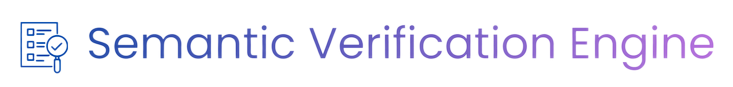

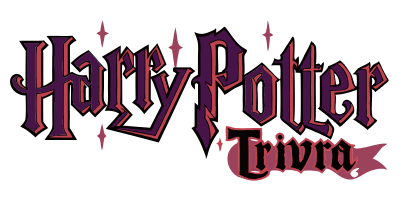

<div style="background-color: #f0e6f7; padding: 10px;">
    <h3 style="text-align:center; color:purple;">Phase 2 Tracer Build: Generation of Synthetic Questions with LLM </h3>
</div>

## Generate Synthetic questions (Sprint 2.2)

**Goal**:<br>
**Workdflow**:

---


## Setup and Imports

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path
import yaml

sys.path.append('..')
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
from typing import List, Tuple
# --- Project-Specific Imports ---
import ds_utils.notebook_config as nb_cfg
from ds_utils import eda_scripts as eda
from ds_utils.ds_constants import QuestionType, QuestionSource
import ds_utils.tracer_utils as tu
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


---

## 1: Generate Synthetic Questions

- Book:   *Harry Potter and the Deathly Hallows*
- Chapters: *[30-35]*
- Question types: FR x 30, EX x 30, and MCQ x 30

In [2]:
DATASET_ID = "phase2_tracer_v0_synthetic"

In [3]:
RANDOM_SEED = 26

def create_synthetic_generation_run_yaml(yaml_id: str, book_prefix: str, 
                                         book_dir: Path, chapter_num: List[int], 
                                         prompt_dir: Path, question_types: List[str]) -> dict:
    """
    Generates a structured experiment configuration dictionary for synthetic question generation.
    Groups specified chapters into pairs and maps them to prompt templates for each question type.
    """
    
    ## 1. Setup
    # 1.1 Gather the relevant chapters and create pairs
    chapter_files = sorted([book_dir / f"{book_prefix}_chapter_{i:02d}.txt" for i in chapter_num])
    
    chapter_pairs = []
    for i in range(0, len(chapter_files), 2):
        pair = chapter_files[i:i+2]
        chapter_pairs.append(pair)

    # 1.2 Get prompts for each question type
    prompts = {}
    for qtype in question_types:
        found_prompts = list(prompt_dir.glob(f"{qtype.lower()}_*.txt"))
        prompts[qtype] = found_prompts
                
    # 2. Create YAML structure
    runs = []    
    for qtype in question_types:
        for pair in chapter_pairs:
            rel_pair = [[f"data/06_books/{f.name}" for f in pair]]
            rel_prompt = f"scripts/pipelines/generate_questions/prompts/{prompts[qtype][0].name}"
            ch_a_num = pair[0].stem.split('_')[-1]
            ch_b_num = pair[1].stem.split('_')[-1]
            
            runs.append({
                'version': f"{qtype}_{book_prefix}_ch{ch_a_num}_{ch_b_num}", 
                'question_type': qtype,
                'prompt_file': rel_prompt,
                'source_text_files': rel_pair, 
                'source_info': [f"{book_prefix} Chapter {ch_a_num}", f"{book_prefix} Chapter {ch_b_num}"], 
                'output_files': None,
                'model_parameters': {
                    'temperature': 0.7 
                },
                'metrics': {
                    'tokens': {
                        'input_cached': 0,
                        'input_uncached': 0,
                        'output': 0,
                        'total': 0
                    }
                },
                'status': 'pending',
                'notes': f"Automated run for {qtype}, {book_prefix}, chapters {ch_a_num}-{ch_b_num}",
                'status_history': []
            })

    # 3. Build the full experiment object
    return {
        'metadata': {
            'project': 'Semantic Verification Engine',
            'owner': 'reema sipra',
            'version': 0
        },
        'experiments': [{
            'id': yaml_id,
            'model': 'models/gemini-2.5-flash',
            'common_parameters': {
                'max_output_tokens': 30000,
                'top_p': 0.95,
                'candidate_count': 1
            },
            'runs': runs
        }]
    }

In [4]:
## Toggle to trigger experiment YAML update and dataset batch creation
TRIGGER_TRACER_UPDATE = False

# Setup
YAML_ID = DATASET_ID + "_generation"
BOOKS_DIR = nb_cfg.BOOK_TEXT
book_prefix = 'deathly_hallows'
chapter_num = list(range(30, 36))
question_types = ['FR', 'EX', 'MCQ']
prompt_dir = nb_cfg.PROMPTS_DIR
TEST_RUN = False  # Set to True to limit to 1 batch for testing

## Create yaml file for the runs:
if TRIGGER_TRACER_UPDATE:
    yaml_file_content = create_synthetic_generation_run_yaml(YAML_ID, book_prefix, 
                                                             BOOKS_DIR, chapter_num, 
                                                             prompt_dir, question_types)
    
    # write yaml to file
    yaml_output_path = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation" / f"{YAML_ID}.yaml"
    with open(yaml_output_path, "w") as f:
        yaml.dump(yaml_file_content, f, sort_keys=False, indent=2)
    num_runs = len(yaml_file_content['batch'][0]['runs'])
    print(f"🚀 Created new YAML with {num_runs} runs.")

else:
    print("⏭️ Skipping YAML update and dataset batch creation (Toggle is False).")    

⏭️ Skipping YAML update and dataset batch creation (Toggle is False).


- Gemnini 2.5 Pro has been removed for the free-tier and cannot be used for EX and MCQ as planned.
    - Decision: Use free-tier Gemini 2.5 Flash for all generation and assess results.

- The EX and FR prompts produce answer variations - but the prompts developed for legacy data generate higher quality lexical variations with SBERT in mind
    - Decision: Remove requirement for answer variation from generation prompt to not waste tokens. Rely on prompt 2 (enrichment) for answer variations along with hints and explanation. This also makes sure there is consistency among legacy and synthetic questions.


In [5]:
# setup
response_dir = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation/llm_outputs/00_generation"
batch_prefix = YAML_ID

# retrieve consolidated LLM responses as dataframe
prompt0_tracer_response_df = tu.merge_llm_batch_responses(response_dir, batch_prefix)
prompt0_tracer_response_df.head()
# this will be added in second prompt with better fidelity.
prompt0_tracer_response_df = prompt0_tracer_response_df.drop(columns=['answer_variations'])
# sanity check 1: visual checks
prompt0_tracer_response_df.info()
display(prompt0_tracer_response_df.sample(10, random_state=RANDOM_SEED))

✅ Merged 9 files with total 50 entries.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   question_type     50 non-null     object
 1   category          50 non-null     object
 2   difficulty        50 non-null     object
 3   question          50 non-null     object
 4   answer            50 non-null     object
 5   source_reference  50 non-null     object
 6   source_quote      50 non-null     object
 7   options           18 non-null     object
dtypes: object(8)
memory usage: 3.3+ KB


,question_type,category,difficulty,question,answer,source_reference,source_quote,options
2,Factual Recall (FR),Character Detail,Easy,"Who was the ghost of Ravenclaw Tower, also kno...",Helena Ravenclaw,deathly_hallows Chapter 31,"""When I lived,"" she said stiffly, ""I was Helen...",NaN
43,multiple choice (MCQ),Character Detail,Medium,"According to Dumbledore, what was the primary ...",His mother's protection was within Voldemort's...,deathly_hallows Chapter 35,"""He took your blood,"" said Harry.""Precisely!"" ...","[He was the true master of Death, His mother's..."
10,Factual Recall (FR),Number/Year,Hard,"According to Dumbledore's confession to Harry,...",Several times,deathly_hallows Chapter 35,Years passed. There were rumors about him. The...,NaN
14,multiple choice (MCQ),Character Detail,Medium,What crucial secret did Dumbledore reveal to S...,That a fragment of Voldemort's soul resided wi...,deathly_hallows Chapter 33,Tell him that on the night Lord Voldemort trie...,[That Harry was destined to become an Animagus...
44,multiple choice (MCQ),Character Detail,Medium,What reason did Dumbledore give for repeatedly...,He believed he was not to be trusted with power,deathly_hallows Chapter 35,"I was offered the post of Minister of Magic, n...",[He believed he was not to be trusted with pow...
5,Factual Recall (FR),Character Detail,Medium,Before confronting Voldemort in the Forbidden ...,Neville Longbottom,deathly_hallows Chapter 34,You know Voldemort's snake. Neville? He's got ...,NaN
33,multiple choice (MCQ),Spell/Charm,Medium,What was Luna Lovegood's initial reaction to s...,"She noted it was noisier than expected, having...",deathly_hallows Chapter 30,I've never Stunned anyone except in our D.A. l...,[She was surprised by the spell's effectivenes...
7,Factual Recall (FR),Character Detail,Medium,"In the clearing in the Forbidden Forest, who s...",Rowle,deathly_hallows Chapter 34,"He turned: Hagrid was bound and trussed, tied ...",NaN
9,Factual Recall (FR),Location/Setting,Medium,"When Harry asked Dumbledore where they were, w...",King's Cross station,deathly_hallows Chapter 35,"It looks,"" he said slowly, ""like King's Cross ...",NaN
46,Explanatory (Why/How),Character Arc/Motive,Hard,Why did Albus Dumbledore explicitly ask Severu...,Dumbledore wanted to protect Draco Malfoy's so...,deathly_hallows Chapter 32,"That boy's soul is not yet so damaged,"" said D...",NaN


In [6]:
type_mapping = {
    'Factual Recall (FR)': 'FR',
    'Explanatory (Why/How)': 'EX',
    'multiple choice (MCQ)': 'MCQ'
}
# 2. Apply it to the column
prompt0_tracer_response_df['question_type'] = prompt0_tracer_response_df['question_type'].replace(type_mapping)
prompt0_tracer_response_df['question_type'].value_counts()

question_type
MCQ    18
FR     16
EX     16
Name: count, dtype: int64

In [7]:
prompt0_tracer_response_df.groupby('category').size()

category
Character Arc/Motive     9
Character Detail        15
Creature/Beast           3
Location/Setting         4
Magical Theory/Lore      4
Number/Year              1
Object/Potion            7
Plot Event               3
Spell/Charm              4
dtype: int64

In [8]:
prompt0_tracer_response_df[prompt0_tracer_response_df['category']=='Number/Year']

,question_type,category,difficulty,question,answer,source_reference,source_quote,options
10,FR,Number/Year,Hard,"According to Dumbledore's confession to Harry,...",Several times,deathly_hallows Chapter 35,Years passed. There were rumors about him. The...,NaN


Inapropriate question
- will be kept as a test case for the `qa_validation` pipeline
- filter questions categorized my LLM as numeric / year to have an actual number and a vague ambiguous answer.
- detected cases should be dropped instead of fixed in the validation pipeline.

In [9]:
prompt0_tracer_response_df[prompt0_tracer_response_df['category']=='Character Detail'].sample(10, random_state=RANDOM_SEED)

,question_type,category,difficulty,question,answer,source_reference,source_quote,options
29,FR,Character Detail,Easy,"While in the Shrieking Shack, which Death Eate...",Lucius Malfoy,deathly_hallows Chapter 32,"'Go and fetch Snape.' ... Frightened, stumblin...",NaN
32,FR,Character Detail,Medium,"During the battle in the Great Hall, which pro...",Professor Trelawney,deathly_hallows Chapter 32,"Then, with a bright white flash and a crack, a...",NaN
15,MCQ,Character Detail,Easy,Where did Lily Evans and Severus Snape first e...,In a park playground near their homes,deathly_hallows Chapter 33,"He fell headlong into sunlight, and his feet f...","[In the Forbidden Forest near Hogwarts, On the..."
30,FR,Character Detail,Medium,After Dumbledore questioned if Severus Snape h...,A silver doe,deathly_hallows Chapter 33,'For him?' shouted Snape. 'Expecto Patronum!' ...,NaN
39,MCQ,Character Detail,Easy,Who carried Colin Creevey's body from the grou...,Oliver Wood,deathly_hallows Chapter 34,"""You know what? I can manage him alone, Nevill...","[Neville Longbottom, Rubeus Hagrid, Oliver Woo..."
44,MCQ,Character Detail,Medium,What reason did Dumbledore give for repeatedly...,He believed he was not to be trusted with power,deathly_hallows Chapter 35,"I was offered the post of Minister of Magic, n...",[He believed he was not to be trusted with pow...
5,FR,Character Detail,Medium,Before confronting Voldemort in the Forbidden ...,Neville Longbottom,deathly_hallows Chapter 34,You know Voldemort's snake. Neville? He's got ...,NaN
11,MCQ,Character Detail,Medium,What form did Severus Snape's Patronus take wh...,A silver doe,deathly_hallows Chapter 33,"""For him?"" shouted Snape. ""Expecto Patronum!"" ...","[A silver stag, A silver otter, A silver doe, ..."
41,MCQ,Character Detail,Medium,How did Sirius Black describe the experience o...,Quicker and easier than falling asleep,deathly_hallows Chapter 34,"""Dying? Not at all,"" said Sirius. ""Quicker and...","[A long, peaceful transition, A terrifying voi..."
7,FR,Character Detail,Medium,"In the clearing in the Forbidden Forest, who s...",Rowle,deathly_hallows Chapter 34,"He turned: Hagrid was bound and trussed, tied ...",NaN


- Question language can be vague as to which event it is referring to. e.g. Q.5 *"While in the Shrieking Shack, which Death Eater did Voldemort send to fetch Severus Snape?"*
- Handling through prompts leads to over-direction and poorer quesiton structure (tested with both 2.5 Flash and 3 pro). 
- Instead handle deterministially - since this is not a problem with all questions and some hard-core fans already have enough hints. Avoid frustrating general player by offering "reference" as a pseudo-hint to clarify context.
    - In tracer it will directly quote `source_reference` (only available for synthetic, blank for legacy). Polish, more specific grounding, and natural phrasing is an optimization for later.   
    - The *reference* will be separate (metadata) from the *hints* which are contextual based.

In [10]:
prompt0_tracer_response_df[prompt0_tracer_response_df['question_type']=='EX'].sort_values('difficulty').head()

,question_type,category,difficulty,question,answer,source_reference,source_quote,options
23,EX,Plot Event,Easy,How did Ron and Hermione manage to destroy Huf...,Ron had the idea to go to the Chamber of Secre...,deathly_hallows Chapter 31,"It was Ron, all Ron's idea! said Hermione brea...",NaN
18,EX,Magical Theory/Lore,Hard,"According to Albus Dumbledore, how was Harry's...",Dumbledore explained that Harry's wand had imb...,deathly_hallows Chapter 35,I believe that your wand imbibed some of the p...,NaN
20,EX,Character Arc/Motive,Hard,What was the primary reason Albus Dumbledore d...,Dumbledore feared learning the truth about his...,deathly_hallows Chapter 35,"It was the truth I feared. You see, I never kn...",NaN
22,EX,Character Arc/Motive,Hard,"Why did Helena Ravenclaw, the Gray Lady, revea...",She confessed to Riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",NaN
45,EX,Magical Theory/Lore,Hard,Why did Lord Voldemort order Nagini to kill Se...,Voldemort mistakenly believed that because Sna...,deathly_hallows Chapter 32,"The Elder Wand cannot serve me properly, Sever...",NaN


1. Add `question_source` column = `synthetic` to dataset.
2. Use prompt 1 to add answer variations, hints, and explanations
3. Use prompt 2 to add semantic_entity_ref and semantic_lore_concepts based on the `answer`.

In [11]:
## Dataset processing

# 1. create a baseline tracer synthetic df, sorted by `question_type` and `source_reference` so they can be batched for LLM enrichment together
tracer_synthetic_df = prompt0_tracer_response_df.sort_values(by=['question_type', 'source_reference']).reset_index(drop=True)

# 2. Add the `question_source` column using enum
tracer_synthetic_df['question_source'] = QuestionSource.SYNTHETIC.value

# 3. Add a key identifier for each Q for traceability 
tracer_synthetic_df['temp_qid'] = [f"SYN_{i:03d}" for i in range(len(tracer_synthetic_df))]

# 4. move temp_qid to the beggining of the df
col = "temp_qid"
tracer_synthetic_df = tracer_synthetic_df[[col] + [c for c in tracer_synthetic_df.columns if c != col]]

# 5. Replace all NaN values with None (which becomes null in JSON)
tracer_synthetic_df = tracer_synthetic_df.replace({np.nan: None})

In [12]:
# sanity check
tracer_synthetic_df.info()
tracer_synthetic_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   temp_qid          50 non-null     object
 1   question_type     50 non-null     object
 2   category          50 non-null     object
 3   difficulty        50 non-null     object
 4   question          50 non-null     object
 5   answer            50 non-null     object
 6   source_reference  50 non-null     object
 7   source_quote      50 non-null     object
 8   options           18 non-null     object
 9   question_source   50 non-null     object
dtypes: object(10)
memory usage: 4.0+ KB


,temp_qid,question_type,category,difficulty,question,answer,source_reference,source_quote,options,question_source
0,SYN_000,EX,Character Arc/Motive,Hard,"Why did Helena Ravenclaw, the Gray Lady, revea...",She confessed to Riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",None,synthetic
1,SYN_001,EX,Plot Event,Medium,How did Harry suddenly realize the exact hidin...,He recalled seeing a marble bust of Rowena Rav...,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,None,synthetic
2,SYN_002,EX,Plot Event,Medium,Why did Professor McGonagall instruct Filch to...,She ordered Filch to find Peeves so the polter...,deathly_hallows Chapter 30,Now go and do something constructive! Find Pee...,None,synthetic
3,SYN_003,EX,Plot Event,Easy,How did Ron and Hermione manage to destroy Huf...,Ron had the idea to go to the Chamber of Secre...,deathly_hallows Chapter 31,"It was Ron, all Ron's idea! said Hermione brea...",None,synthetic
4,SYN_004,EX,Character Arc/Motive,Medium,Why did Ron Weasley insist they should tell th...,Ron believed they shouldn't order the house-el...,deathly_hallows Chapter 31,"The house-elves, they'll all be down in the ki...",None,synthetic


  {
    "temp_qid": "SYN_034",
    "question_type": "MCQ",
    "category": "Creature/Beast",
    "difficulty": "Medium",
    "question": "What form did Professor McGonagall's Patronus take when she sent it to alert the other Heads of House?",
    "answer": "Three silver cats with spectacle markings around their eyes.",
    "source_reference": "deathly_hallows Chapter 30",
    "source_quote": "From the tip burst three silver cats with spectacle markings around their eyes. the Patronuses ran sleekly ahead, filling the spiral staircase with silvery light, as Professor McGonagall, Harry, and Luna hurried back down.",
    "options": [
      "A single, powerful lynx.",
      "A shimmering silver griffin.",
      "Three silver cats with spectacle markings around their eyes.",
      "A majestic tiger, her Animagus form."
    ],
    "question_source": "synthetic"
  },

  Field,Value
Source Quote,"""...three silver cats with spectacle markings..."""
Generated Distractor,"""A majestic tiger, her Animagus form."""
Logic Failure,"The model prioritized semantic flair (""majestic tiger"") over grounded fact (McGonagall is a tabby cat)."
Tracer Status,Accepted. The error does not invalidate the correct_answer or the technical integrity of the JSON schema.

Phase 3 Strategic Approach: The "Direct SLM Audit"
When you move into Phase 3, you can implement a Lore Fact Check that is separate from the generation logic. This is essentially a "Reflector" pattern where one model audits another.

The Logic flow for Phase 3:

1. Extract Claims: Use a lightweight model to extract entities from the options.
2. Verify against Context: Compare the extracted entities ("Tiger") against the provided source_quote ("Cats").
3. Flag/drop: If the source quote mentions the entity type (Animals/Patronus form), but the distractor uses a different species, flag it for a Lore Conflict. Then drop.

How the "Drop" Logic integrates into your Pipeline
Since you are documenting this for your portfolio, here is how you can frame the "Audit & Prune" phase:

The Generation Phase: (Current) The LLM generates the initial Synthetic/Enriched data.

The SLM Lore Audit: A smaller, specialized model (or a targeted prompt) reviews the MCQs specifically for distractor consistency.

The Filter Step: If the audit returns LoreConflict: True, the record is moved to a rejected_records.json file instead of the main dataset.

The Yield Metric: You track the "Yield Rate" (e.g., "Our pipeline achieved an 85% pass rate for synthetic MCQs"). This is a professional metric that shows you understand the inherent noise in LLM outputs.

That "Fail-Fast" or Pruning Strategy is a high-integrity design choice. In both Healthcare Data Science and high-end game design, it is often better to have 40 perfect, lore-accurate questions than 50 questions where 10 have subtle hallucinations that erode user trust.

By choosing to flag and drop rather than correct, you are prioritizing Precision over Recall. This makes your final "Gold Dataset" much more valuable because every record has survived a rigorous audit.

How the "Drop" Logic integrates into your Pipeline
Since you are documenting this for your portfolio, here is how you can frame the "Audit & Prune" phase:

The Generation Phase: (Current) The LLM generates the initial Synthetic/Enriched data.

The SLM Lore Audit: A smaller, specialized model (or a targeted prompt) reviews the MCQs specifically for distractor consistency.

The Filter Step: If the audit returns LoreConflict: True, the record is moved to a rejected_records.json file instead of the main dataset.

The Yield Metric: You track the "Yield Rate" (e.g., "Our pipeline achieved an 85% pass rate for synthetic MCQs"). This is a professional metric that shows you understand the inherent noise in LLM outputs.

The "Tiger Case" in a Drop-Logic System
In this design, SYN_034 (the McGonagall question) would follow this path:

Audit Output: {"temp_qid": "SYN_034", "status": "flagged", "reason": "Hallucinated distractor: Tiger"}

Result: The question is excluded from the final SQL database or game-ready JSON.

Outcome: The player never sees the error, and the "Semantic Verification Engine" has successfully protected the integrity of the product.

### Prompt 1

1. Need to use the batch the tracer df instead of the llm json replies directly because of the temp_qid for traceability. Each batch would be for a specific quesetion type. This prevents the LLM needing to task switch within an API call, reducing errors.
2. The same enrichment prompts as legacy. Also using the legacy run_experiment script for enrichment (instead of generation script)

In [13]:
# create a batch for each question type, write as json, and save to dir
SAVE_DIR = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation/llm_outputs/01_batches_for_enrich"
filename_prefix = DATASET_ID + "_staging_"

# create a list of batch contents
batch_content = []
for qtype in tracer_synthetic_df['question_type'].unique():
    type_subset = tracer_synthetic_df[tracer_synthetic_df['question_type']== qtype]
    batch_content.append({
            "type": qtype,
            "data": type_subset.to_dict(orient='records')
        })
    
# write content to individual files
for idx, batch in enumerate(batch_content, 1):
    file_name = filename_prefix + f"{batch['type']}_batch_{idx:02d}.json"
    full_path = SAVE_DIR / file_name
    with open(full_path, 'w', encoding='utf-8') as f:
        json.dump(batch['data'], f, indent=2, ensure_ascii=False)

In [ ]:
## Toggle to trigger experiment YAML update and dataset batch creation
TRIGGER_TRACER_UPDATE = False

## setup
TEST_RUN = False

# synthetic questions source
BATCH_DIR = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation/llm_outputs/01_batches_for_enrich"
# same prompt as legacy to add enrichment columns (answse_variations, hints, explanation)
PROMPT_PATH = nb_cfg.SCRIPTS_DIR / "research/legacy_update/legacy_enrichment_prompt_master.txt"
# location to save yaml filel
YAML_PATH = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation"

YAML_ID_ENR_LEX = "_enrichment_lex"
EXPERIMENT_ID = DATASET_ID + YAML_ID_ENR_LEX
DESCRIPTION = "Phase 2 Tracer build, Synthetic generated dataset lexical enrichment with LLM to match standard schema (answer variations, hints, explanations)"

if TRIGGER_TRACER_UPDATE: 
    # 1. Generate experiment YAML content using helper method from tracer_utils (tu) module.
    # Logic: 1 for test, 0 for "all"
    limit_val = 1 if TEST_RUN else 0
    # Use tracer_utils.py module to generate the yaml needed for the api script 
    synthetic_enrichment_yaml = tu.generate_experiment_yaml(BATCH_DIR, 
                                                            PROMPT_PATH, 
                                                            EXPERIMENT_ID,
                                                            DESCRIPTION, 
                                                            limit=limit_val)
    # 2. Save to a new YAML file
    yaml_output_path = YAML_PATH / f"{EXPERIMENT_ID}.yaml"
    with open(yaml_output_path, "w") as f:
        yaml.dump(synthetic_enrichment_yaml, f, sort_keys=False, indent=2)
    num_runs = len(synthetic_enrichment_yaml['experiments'][0]['runs'])
    print(f"🚀 Created new YAML with {num_runs} runs.")
    
else:
    print("⏭️ Skipping YAML update and dataset batch creation (Toggle is False).")    

🚀 Created new YAML with 3 runs.


Using same [script](../../scripts/research/legacy_update/legacy_enrichment_script.py) as legacy dataset to add enrichment columns. Scripts was run externally and the LLM response are [here](scripts/research/question_generation/tracer_dataset_generation/llm_outputs/02_enrichment_lex). 

In [ ]:
## retrieve the LLM enrichment repsonses
# setup
prompt1_response_dir = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation/llm_outputs/02_enrichmed_lex"
batch_prefix_1 = EXPERIMENT_ID

# retrieve consolidated LLM responses as dataframe using helper method from tracer_utils module
prompt1_response_df = tu.merge_llm_batch_responses(prompt1_response_dir, batch_prefix_1)

# sanity check: visual review
prompt1_response_df.info()
display(prompt1_response_df.head())

✅ Merged 3 files with total 50 entries.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   question_id        50 non-null     object
 1   question_type      50 non-null     object
 2   question           50 non-null     object
 3   answer             50 non-null     object
 4   hint_1             50 non-null     object
 5   hint_2             50 non-null     object
 6   hint_3             50 non-null     object
 7   explanation        50 non-null     object
 8   answer_variations  50 non-null     object
dtypes: object(9)
memory usage: 3.6+ KB


,question_id,question_type,question,answer,hint_1,hint_2,hint_3,explanation,answer_variations
0,SYN_000,EX,"Why did Helena Ravenclaw, the Gray Lady, revea...",She confessed to Riddle because he was flatter...,Consider how Tom Riddle typically manipulated ...,The difference lay in Riddle's emotional appro...,The ghost was susceptible to appeals that vali...,Helena confessed to Riddle because he flattere...,[[Comprehensive]: Helena confessed to Riddle b...
1,SYN_001,EX,How did Harry suddenly realize the exact hidin...,He recalled seeing a marble bust of Rowena Rav...,Harry's memory of a seemingly insignificant pa...,He remembered hiding a specific school book in...,"Sometimes, the most important answers are foun...",Harry realized the diadem's location by connec...,[[Comprehensive]: Harry recognized the diadem'...
2,SYN_002,EX,Why did Professor McGonagall instruct Filch to...,She ordered Filch to find Peeves so the polter...,Professor McGonagall was preparing Hogwarts fo...,Consider Peeves's usual behavior and his capac...,"In dire circumstances, even the most troubleso...","McGonagall, recognizing the dire situation, sa...",[[Comprehensive]: McGonagall instructed Filch ...
3,SYN_003,EX,How did Ron and Hermione manage to destroy Huf...,Ron had the idea to go to the Chamber of Secre...,"What unique, extremely potent magical item was...","Ron demonstrated an unexpected skill, mimickin...","Sometimes, the key to solving new problems lie...",Ron cleverly realized they could use a basilis...,[[Comprehensive]: Ron suggested the Chamber of...
4,SYN_004,EX,Why did Ron Weasley insist they should tell th...,Ron believed they shouldn't order the house-el...,Ron had a significant personal experience invo...,Recall a recent tragic event that deeply affec...,"The value of all lives, regardless of status, ...",Ron's insistence stemmed from his newfound com...,[[Comprehensive]: Ron believed house-elves sho...


In [28]:
columns_to_add = ['question_id','hint_1', 'hint_2', 'hint_3', 'explanation', 'answer_variations']

tracer_syn_df_enriched = pd.merge(tracer_synthetic_df.copy(),
                                  prompt1_response_df[columns_to_add],
                                  how='left', 
                                  left_on='temp_qid',
                                  right_on='question_id')

tracer_syn_df_enriched.info()

# sanity check
# 1. Ensure every row matched
assert tracer_syn_df_enriched["question_id"].notna().all(), ("Some tracer rows did not find a matching LLM response")
# 2. Ensure identity equality
assert (tracer_syn_df_enriched['temp_qid']==tracer_syn_df_enriched['question_id']).all(), "temp_qid and question_id mismatch after merge"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   temp_qid           50 non-null     object
 1   question_type      50 non-null     object
 2   category           50 non-null     object
 3   difficulty         50 non-null     object
 4   question           50 non-null     object
 5   answer             50 non-null     object
 6   source_reference   50 non-null     object
 7   source_quote       50 non-null     object
 8   options            18 non-null     object
 9   question_source    50 non-null     object
 10  question_id        50 non-null     object
 11  hint_1             50 non-null     object
 12  hint_2             50 non-null     object
 13  hint_3             50 non-null     object
 14  explanation        50 non-null     object
 15  answer_variations  50 non-null     object
dtypes: object(16)
memory usage: 6.4+ KB


In [29]:
# drop the `question_id` column -> redundant 
tracer_syn_df_enriched = tracer_syn_df_enriched.drop(columns='question_id')

# view sample 
tracer_syn_df_enriched.sample(5,random_state=RANDOM_SEED)

,temp_qid,question_type,category,difficulty,question,answer,source_reference,source_quote,options,question_source,hint_1,hint_2,hint_3,explanation,answer_variations
2,SYN_002,EX,Plot Event,Medium,Why did Professor McGonagall instruct Filch to...,She ordered Filch to find Peeves so the polter...,deathly_hallows Chapter 30,Now go and do something constructive! Find Pee...,None,synthetic,Professor McGonagall was preparing Hogwarts fo...,Consider Peeves's usual behavior and his capac...,"In dire circumstances, even the most troubleso...","McGonagall, recognizing the dire situation, sa...",[[Comprehensive]: McGonagall instructed Filch ...
43,SYN_043,MCQ,Character Detail,Easy,Where did Lily Evans and Severus Snape first e...,In a park playground near their homes,deathly_hallows Chapter 33,"He fell headlong into sunlight, and his feet f...","[In the Forbidden Forest near Hogwarts, On the...",synthetic,Their first meeting happened before they knew ...,Think about a common place for children to pla...,Their childhood introduction occurred in a mun...,Lily Evans and Severus Snape first encountered...,"[park playground, playground near their homes]"
10,SYN_010,EX,Character Arc/Motive,Medium,Why was Lord Voldemort certain that Harry Pott...,"Voldemort believed that Harry's ""one great fla...",deathly_hallows Chapter 32,Neither of you understands Potter as I do. He ...,None,synthetic,Voldemort thought he understood Harry's core w...,Harry's deepest desire was always to protect h...,The villain often mistakes the hero's greatest...,Voldemort was certain Harry would come to him ...,[[Comprehensive]: Voldemort knew Harry's 'flaw...
14,SYN_014,EX,Character Arc/Motive,Hard,What was the primary reason Albus Dumbledore d...,Dumbledore feared learning the truth about his...,deathly_hallows Chapter 35,"It was the truth I feared. You see, I never kn...",None,synthetic,Consider Dumbledore's greatest personal regret...,He was afraid of uncovering a painful truth ab...,The weight of unresolved guilt and the potenti...,Dumbledore delayed confronting Grindelwald pri...,[[Comprehensive]: Dumbledore delayed confronti...
44,SYN_044,MCQ,Character Detail,Easy,Who carried Colin Creevey's body from the grou...,Oliver Wood,deathly_hallows Chapter 34,"""You know what? I can manage him alone, Nevill...","[Neville Longbottom, Rubeus Hagrid, Oliver Woo...",synthetic,This person was a former Gryffindor Quidditch ...,The individual carrying Colin was a Hogwarts a...,The student who carried Colin's body was known...,"After the Battle of Hogwarts, Oliver Wood, the...",[Oliver Wood]


## Prompt 2: 

1. Need to use the batch the tracer df instead of the llm json replies directly because of the temp_qid for traceability. Each batch would be for a specific quesetion type. This prevents the LLM needing to task switch within an API call, reducing errors.
2. The same enrichment prompts as legacy. Also using the legacy run_experiment script for enrichment (instead of generation script)

In [ ]:
## Toggle to trigger experiment YAML update and dataset batch creation
TRIGGER_TRACER_UPDATE = True

## setup
TEST_RUN = False

# synthetic questions source
BATCH_DIR = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation/llm_outputs/01_batches_for_enrich"
# same prompt as legacy to add enrichment columns (answse_variations, hints, explanation)
PROMPT_PATH = nb_cfg.SCRIPTS_DIR / "research/legacy_update/legacy_context_variations_master.txt"
# location to save yaml filel
YAML_PATH = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation"

YAML_ID_ENR_CON = "_enrichment_context"
EXPERIMENT_ID = DATASET_ID + YAML_ID_ENR_CON
DESCRIPTION = "Phase 2 Tracer build, Synthetic generated dataset answer contextual enrichment with LLM to match standard schema (semantic entity reference & lore concepts)"

if TRIGGER_TRACER_UPDATE: 
    # 1. Generate experiment YAML content using helper method from tracer_utils (tu) module.
    # Logic: 1 for test, 0 for "all"
    limit_val = 1 if TEST_RUN else 0
    # Use tracer_utils.py module to generate the yaml needed for the api script 
    synthetic_enrichment_yaml = tu.generate_experiment_yaml(BATCH_DIR, 
                                                            PROMPT_PATH, 
                                                            EXPERIMENT_ID,
                                                            DESCRIPTION, 
                                                            limit=limit_val)
    # 2. Save to a new YAML file
    yaml_output_path = YAML_PATH / f"{EXPERIMENT_ID}.yaml"
    with open(yaml_output_path, "w") as f:
        yaml.dump(synthetic_enrichment_yaml, f, sort_keys=False, indent=2)
    num_runs = len(synthetic_enrichment_yaml['experiments'][0]['runs'])
    print(f"🚀 Created new YAML with {num_runs} runs.")
    
else:
    print("⏭️ Skipping YAML update and dataset batch creation (Toggle is False).")    

🚀 Created new YAML with 3 runs.


In [31]:
## retrieve the LLM enrichment repsonses
# setup
prompt2_response_dir = nb_cfg.SCRIPTS_DIR / "research/question_generation/tracer_dataset_generation/llm_outputs/03_enriched _context_var"
batch_prefix_2 = EXPERIMENT_ID

# retrieve consolidated LLM responses as dataframe using helper method from tracer_utils module
prompt2_response_df = tu.merge_llm_batch_responses(prompt2_response_dir, batch_prefix_2)

# sanity check: visual review
prompt2_response_df.info()
display(prompt2_response_df.head())

✅ Merged 3 files with total 50 entries.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   original_question_id    50 non-null     object
 1   semantic_entity_refs    50 non-null     object
 2   semantic_lore_concepts  50 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


,original_question_id,semantic_entity_refs,semantic_lore_concepts
0,SYN_016,[],"[Stunning spell effect, Stupefy charm, Magical..."
1,SYN_017,[],"[Vanishing spell mechanics, Ravenclaw riddle a..."
2,SYN_018,"[Helena Ravenclaw, The Gray Lady, Ravenclaw gh...","[Hogwarts ghost, Founder's daughter]"
3,SYN_019,[],"[Diadem hiding place, Horcrux hiding location,..."
4,SYN_020,"[Fred Weasley, Weasley twin]","[Battle of Hogwarts casualty, Weasley family d..."


In [38]:
# merge enrichment columns to tracer df
final_tracer_syn_df = pd.merge(tracer_syn_df_enriched.copy(),
                               prompt2_response_df,
                               how='left', 
                               left_on='temp_qid',
                               right_on='original_question_id')

final_tracer_syn_df.info()

# sanity check
# 1. Ensure every row matched
assert final_tracer_syn_df["original_question_id"].notna().all(), ("Some tracer rows did not find a matching LLM response")
# 2. Ensure identity equality
assert (final_tracer_syn_df['temp_qid']==final_tracer_syn_df['original_question_id']).all(), "temp_qid and original_question_id mismatch after merge"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   temp_qid                50 non-null     object
 1   question_type           50 non-null     object
 2   category                50 non-null     object
 3   difficulty              50 non-null     object
 4   question                50 non-null     object
 5   answer                  50 non-null     object
 6   source_reference        50 non-null     object
 7   source_quote            50 non-null     object
 8   options                 18 non-null     object
 9   question_source         50 non-null     object
 10  hint_1                  50 non-null     object
 11  hint_2                  50 non-null     object
 12  hint_3                  50 non-null     object
 13  explanation             50 non-null     object
 14  answer_variations       50 non-null     object
 15  original

In [39]:
# drop the redundant 'original_question_id' column
final_tracer_syn_df = final_tracer_syn_df.drop(columns='original_question_id')

In [41]:
# review df
print("First five records from the final tracer synthetic dataset")
display(final_tracer_syn_df.head())

# closer look at samples
columns_to_view = ['question_type', 'question', 'answer','semantic_entity_refs', 'semantic_lore_concepts']
print("View 3 random questions:")
display(final_tracer_syn_df[columns_to_view].sample(3, random_state=RANDOM_SEED).to_dict(orient='records'))

First five records from the final tracer synthetic dataset


,temp_qid,question_type,category,difficulty,question,answer,source_reference,source_quote,options,question_source,hint_1,hint_2,hint_3,explanation,answer_variations,semantic_entity_refs,semantic_lore_concepts
0,SYN_000,EX,Character Arc/Motive,Hard,"Why did Helena Ravenclaw, the Gray Lady, revea...",She confessed to Riddle because he was flatter...,deathly_hallows Chapter 30,"You've already told someone this story, haven'...",None,synthetic,Consider how Tom Riddle typically manipulated ...,The difference lay in Riddle's emotional appro...,The ghost was susceptible to appeals that vali...,Helena confessed to Riddle because he flattere...,[[Comprehensive]: Helena confessed to Riddle b...,"[Helena Ravenclaw, The Gray Lady, Tom Riddle, ...","[Horcrux creation, Flattery and manipulation, ..."
1,SYN_001,EX,Plot Event,Medium,How did Harry suddenly realize the exact hidin...,He recalled seeing a marble bust of Rowena Rav...,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,None,synthetic,Harry's memory of a seemingly insignificant pa...,He remembered hiding a specific school book in...,"Sometimes, the most important answers are foun...",Harry realized the diadem's location by connec...,[[Comprehensive]: Harry recognized the diadem'...,"[Harry Potter, Diadem Horcrux, Rowena Ravencla...","[Horcrux hunting, Memory recall, Hidden object..."
2,SYN_002,EX,Plot Event,Medium,Why did Professor McGonagall instruct Filch to...,She ordered Filch to find Peeves so the polter...,deathly_hallows Chapter 30,Now go and do something constructive! Find Pee...,None,synthetic,Professor McGonagall was preparing Hogwarts fo...,Consider Peeves's usual behavior and his capac...,"In dire circumstances, even the most troubleso...","McGonagall, recognizing the dire situation, sa...",[[Comprehensive]: McGonagall instructed Filch ...,"[Minerva McGonagall, Professor McGonagall, Pee...","[Battle of Hogwarts, Enlisting non-traditional..."
3,SYN_003,EX,Plot Event,Easy,How did Ron and Hermione manage to destroy Huf...,Ron had the idea to go to the Chamber of Secre...,deathly_hallows Chapter 31,"It was Ron, all Ron's idea! said Hermione brea...",None,synthetic,"What unique, extremely potent magical item was...","Ron demonstrated an unexpected skill, mimickin...","Sometimes, the key to solving new problems lie...",Ron cleverly realized they could use a basilis...,[[Comprehensive]: Ron suggested the Chamber of...,"[Ron Weasley, Hermione Granger, Hufflepuff's C...","[Horcrux destruction, Parseltongue imitation, ..."
4,SYN_004,EX,Character Arc/Motive,Medium,Why did Ron Weasley insist they should tell th...,Ron believed they shouldn't order the house-el...,deathly_hallows Chapter 31,"The house-elves, they'll all be down in the ki...",None,synthetic,Ron had a significant personal experience invo...,Recall a recent tragic event that deeply affec...,"The value of all lives, regardless of status, ...",Ron's insistence stemmed from his newfound com...,[[Comprehensive]: Ron believed house-elves sho...,"[Ron Weasley, House-elves, Dobby, Free Elf Dobby]","[House-elf welfare, SPEW advocacy, Compassion ..."


View 3 random questions:


[{'question_type': 'EX',
  'question': 'Why did Professor McGonagall instruct Filch to find Peeves during the preparations for battle at Hogwarts?',
  'answer': "She ordered Filch to find Peeves so the poltergeist could be enlisted to help defend the school, despite Filch's bewilderment at the request.",
  'semantic_entity_refs': ['Minerva McGonagall',
   'Professor McGonagall',
   'Peeves',
   'Hogwarts poltergeist',
   'Argus Filch',
   'Hogwarts caretaker'],
  'semantic_lore_concepts': ['Battle of Hogwarts',
   'Enlisting non-traditional help',
   'Hogwarts defense',
   "Poltergeist's nature"]},
 {'question_type': 'MCQ',
  'question': 'Where did Lily Evans and Severus Snape first encounter each other as children?',
  'answer': 'In a park playground near their homes',
  'semantic_entity_refs': ['Lily Evans', 'Severus Snape'],
  'semantic_lore_concepts': ['Childhood friendship',
   'First encounter',
   'Muggle world setting']},
 {'question_type': 'EX',
  'question': 'Why was Lord Vol